In [ ]:
import operator
from typing import Annotated, Literal, TypedDict

from dotenv import load_dotenv
from langchain.messages import HumanMessage, SystemMessage
from langchain_mistralai import ChatMistralAI
from langgraph.graph import END, START, StateGraph
from pydantic import BaseModel, Field

load_dotenv()

True

# workflow

In [46]:
evaluator= ChatMistralAI(model='mistral-large-latest')

model= ChatMistralAI(model='mistral-small-latest')

coder= ChatMistralAI(model='codestral-latest')

In [47]:
class Evaluate_Input(BaseModel):
    errors: list[str]= Field(description= 'List summary of all the errors that are present in the code in a single and simple sentence.')
    
class Make_Changes(BaseModel):
    updated_code: str = Field(description='New and updated code solving the errors in the previous code.')
    thought_process: str= Field(description='Detailed thought process of how and why the code was changed to fix the errors.')
    

In [48]:
structured_evaluator= evaluator.with_structured_output(Evaluate_Input)
structured_coder= coder.with_structured_output(Make_Changes)

In [49]:
class FixerState(TypedDict):
    
    user_prompt: str
    current_code: str
    errors: str
    output_current_code: str
    code_history: Annotated[list[str], operator.add]
    error_history: Annotated[list[str], operator.add]
    thought_process_history: Annotated[list[str], operator.add]
    
    itr: int
    max_itr: int

In [50]:
def evaluate_input(state: FixerState): # model identifies error
    current_code= state['current_code']
    
    messages= [
        SystemMessage(content= 'You are a professional code analyzer that is an expert at finding bugs and errors in code just by looking at it without any error reports.'),
        HumanMessage(content= f""" User message: {state['user_prompt']}
                     Current code: {current_code} 
                     
                     Your job is to find errors in the code and report only a simple single sentence summary of each error in a list.""")
    ]
    
    response= structured_evaluator.invoke(messages)
    
    return {'current_code': current_code, 'errors': response.errors, 'error_history': [response.errors]}
    
def make_changes(state: FixerState): # model generates updated code
    # x='b'
    # return {'current_code': x}
    pass
def evaluate_changes(state: FixerState): # the suggested code is run and evaluated
    x=['c']
    return {'code_history': x}
def provide_summary(state: FixerState): # the final output based on thought process
    x=['d']
    return {'thought_process': x}
def provide_failure_summary(state: FixerState): # the final output if the error could not be solved
    x=['e']
    return {'thought_process': x}

def check_condition(state: FixerState): # to check if error exists in updated code
    has_error = False
    max_retries= False
    if has_error:
        return 'retry'
    elif max_retries:
        return 'trial_summary'
    else:
        return 'done'

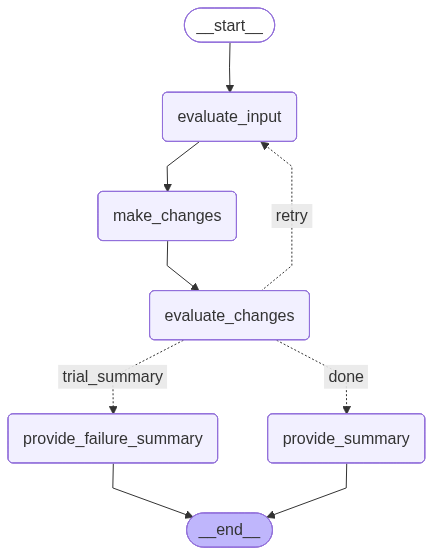

In [51]:
graph = StateGraph(FixerState)

graph.add_node('evaluate_input', evaluate_input)
graph.add_node('make_changes', make_changes)
graph.add_node('evaluate_changes', evaluate_changes)
graph.add_node('provide_summary', provide_summary)
graph.add_node('provide_failure_summary', provide_failure_summary)

graph.add_edge(START, 'evaluate_input')
graph.add_edge('evaluate_input', 'make_changes')
graph.add_edge('make_changes', 'evaluate_changes')

graph.add_conditional_edges(
    'evaluate_changes',
    check_condition,
    {
        'retry': 'evaluate_input',
        'trial_summary': 'provide_failure_summary',
        'done': 'provide_summary'
    }
)

graph.add_edge('provide_summary', END)
graph.add_edge('provide_failure_summary', END)

chatbot= graph.compile()
chatbot

In [54]:
initial_state= {
    'user_prompt': "Why is there no output?",
    'current_code': """prnit('hello')""",
    'itr':1,
    'max_itr':3
}

final_state= chatbot.invoke(initial_state)
final_state

{'user_prompt': 'Why is there no output?',
 'current_code': "prnit('hello')",
 'errors': ['The function `prnit` is misspelled; it should be `print`.'],
 'code_history': ['c'],
 'error_history': [['The function `prnit` is misspelled; it should be `print`.']],
 'thought_process_history': [],
 'itr': 1,
 'max_itr': 3}

# Sandbox check

In [18]:
from llm_sandbox import SandboxBackend, SandboxSession

session = SandboxSession(
    backend=SandboxBackend.DOCKER,
    lang="python",
    keep_template=True
)

codes = [
        "print('Hello from iteration 1')",
    ]

session.open()

for i, code in enumerate(codes, 1):
    print(f"\n--- Iteration {i} ---")

    result = session.run(code)

    print("STDOUT:", result.stdout)
    print("STDERR:", result.stderr)
    print("EXIT CODE:", result.exit_code)

session.close()


--- Iteration 1 ---
STDOUT: Hello from iteration 1

STDERR: 
EXIT CODE: 0
